In [26]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [27]:
# Set Directories

# Data Files
data_dir = '../data/'
temp_data_dir = data_dir + 'raw/'

# CSV Files
output_dir = '../output/tables/'

# Plots
plots_dir = '../output/figures/'

## 1. Data Retrieval

Datasets retrieved from:
* Cryptocurrencies:
    * Bitcoin: Yahoo Finance (BTC-USD)
    * Ethereum: Yahoo Finance (ETH-USD)

* Equities:
    * S&P 500: Yahoo Finance (S&P 500 ^GSPC)
    * Vanguard Total Stock Market ETF: Yahoo Finance (VTI)

* Bonds:
    * US 10-Year Treasury yield: FRED (not used in the end)
    * US Aggregate Bond Index: Yahoo Finance (AGG)
    * 20+ Year Treasury Bond ETF: Yahoo Finance (TLT)

Daily closing prices were retrieved from Yahoo Finance over the period 2014-2025. 


In [28]:
# Helper Function - Get data from Yahoo Finance
def get_yf_data(ticker_name, start_date, end_date):

    # Pull data from Yahoo Finance
    raw_data = yf.download(ticker_name, start=start_date, end=end_date, auto_adjust=False)

    data = raw_data.reset_index()

    # Flatten MultiIndex (if exists)
    if isinstance(data.columns, pd.MultiIndex):
        data.columns = [col[0] for col in data.columns]

    data = data.rename(columns={
        'Date': 'date',
        'Open': 'open',
        'High': 'high',
        'Low': 'low',
        'Close': 'close',
        'Adj Close': 'adj_close',
        'Volume': 'volume'
    })

    data['date'] = pd.to_datetime(data['date'])
    data = data[['date', 'open', 'high', 'low', 'close', 'adj_close', 'volume']]
    return data

In [29]:
# Bitcoin
btc_data = get_yf_data('BTC-USD', '2014-01-01', '2026-01-01') # Only start from 17 Sept 2014
btc_data

[*********************100%***********************]  1 of 1 completed


,date,open,high,low,close,adj_close,volume
0,2014-09-17,465.864014,468.174011,452.421997,457.334015,457.334015,21056800
1,2014-09-18,456.859985,456.859985,413.104004,424.440002,424.440002,34483200
2,2014-09-19,424.102997,427.834991,384.532013,394.795990,394.795990,37919700
3,2014-09-20,394.673004,423.295990,389.882996,408.903992,408.903992,36863600
4,2014-09-21,408.084991,412.425995,393.181000,398.821014,398.821014,26580100
...,...,...,...,...,...,...,...
4119,2025-12-27,87301.429688,87874.781250,87182.976562,87802.156250,87802.156250,13741199310
4120,2025-12-28,87799.343750,87986.890625,87394.953125,87835.835938,87835.835938,15156557929
4121,2025-12-29,87835.789062,90299.156250,86717.914062,87138.140625,87138.140625,48411625849
4122,2025-12-30,87134.351562,89297.937500,86735.546875,88430.132812,88430.132812,35586356225


In [30]:
# Ethereum
eth_data = get_yf_data('ETH-USD', '2014-01-01', '2026-01-01') # Only start from 9 Nov 2017
eth_data

[*********************100%***********************]  1 of 1 completed


,date,open,high,low,close,adj_close,volume
0,2017-11-09,308.644989,329.451996,307.056000,320.884003,320.884003,893249984
1,2017-11-10,320.670990,324.717987,294.541992,299.252991,299.252991,885985984
2,2017-11-11,298.585999,319.453003,298.191986,314.681000,314.681000,842300992
3,2017-11-12,314.690002,319.153015,298.513000,307.907990,307.907990,1613479936
4,2017-11-13,307.024994,328.415009,307.024994,316.716003,316.716003,1041889984
...,...,...,...,...,...,...,...
2970,2025-12-27,2925.745117,2957.300537,2917.271240,2947.998291,2947.998291,7378783299
2971,2025-12-28,2947.898193,2957.138672,2925.745361,2948.568115,2948.568115,9227601389
2972,2025-12-29,2948.559082,3051.941895,2908.748047,2934.538330,2934.538330,25957694515
2973,2025-12-30,2934.416260,3002.804688,2916.330078,2971.416748,2971.416748,18816704381


In [31]:
# S&P 500
sp500_data = get_yf_data('^GSPC', '2014-01-01', '2026-01-01')
sp500_data

[*********************100%***********************]  1 of 1 completed


,date,open,high,low,close,adj_close,volume
0,2014-01-02,1845.859985,1845.859985,1827.739990,1831.979980,1831.979980,3080600000
1,2014-01-03,1833.209961,1838.239990,1829.130005,1831.369995,1831.369995,2774270000
2,2014-01-06,1832.310059,1837.160034,1823.729980,1826.770020,1826.770020,3294850000
3,2014-01-07,1828.709961,1840.099976,1828.709961,1837.880005,1837.880005,3511750000
4,2014-01-08,1837.900024,1840.020020,1831.400024,1837.489990,1837.489990,3652140000
...,...,...,...,...,...,...,...
3013,2025-12-24,6904.910156,6937.319824,6904.910156,6932.049805,6932.049805,1798270000
3014,2025-12-26,6936.020020,6945.770020,6921.600098,6929.939941,6929.939941,2586550000
3015,2025-12-29,6903.600098,6920.209961,6888.759766,6905.740234,6905.740234,3541750000
3016,2025-12-30,6900.439941,6913.250000,6893.470215,6896.240234,6896.240234,3309930000


In [32]:
# Vanguard Total Stock Market ETF
vti_data = get_yf_data('VTI', '2014-01-01', '2026-01-01')
vti_data

[*********************100%***********************]  1 of 1 completed


,date,open,high,low,close,adj_close,volume
0,2014-01-02,95.760002,95.760002,94.820000,95.080002,77.400810,3728200
1,2014-01-03,95.290001,95.440002,94.949997,95.059998,77.384537,3206300
2,2014-01-06,95.500000,95.559998,94.669998,94.809998,77.181023,3169400
3,2014-01-07,95.190002,95.589996,95.099998,95.419998,77.677589,2617200
4,2014-01-08,95.440002,95.620003,95.089996,95.489998,77.734573,3783100
...,...,...,...,...,...,...,...
3013,2025-12-24,338.779999,340.100006,338.709991,339.880005,338.818512,4006500
3014,2025-12-26,340.140015,340.329987,339.170013,339.670013,338.609161,3543600
3015,2025-12-29,338.399994,339.269989,337.570007,338.390015,337.333160,3795900
3016,2025-12-30,338.390015,338.779999,337.750000,337.850006,336.794830,3576200


In [33]:
# US Aggregate Bond Index
agg_data = get_yf_data('AGG', '2014-01-01', '2026-01-01')
agg_data

[*********************100%***********************]  1 of 1 completed


,date,open,high,low,close,adj_close,volume
0,2014-01-02,106.449997,106.570000,106.430000,106.500000,76.418907,1346600
1,2014-01-03,106.449997,106.629997,106.389999,106.540001,76.447594,2293500
2,2014-01-06,106.529999,106.680000,106.529999,106.680000,76.548035,4413900
3,2014-01-07,106.739998,106.779999,106.669998,106.730003,76.583961,1255700
4,2014-01-08,106.570000,106.620003,106.400002,106.410004,76.354294,1090800
...,...,...,...,...,...,...,...
3013,2025-12-24,99.900002,100.040001,99.849998,100.019997,99.047279,4483900
3014,2025-12-26,100.129997,100.150002,99.970001,100.040001,99.067085,6503700
3015,2025-12-29,100.120003,100.190002,100.059998,100.160004,99.185928,7886700
3016,2025-12-30,100.059998,100.180000,100.029999,100.120003,99.146317,7955800


In [34]:
# 20+ Year Treasury Bond ETF (TLT)
tlt_data = get_yf_data('TLT', '2014-01-01', '2026-01-01')
tlt_data

[*********************100%***********************]  1 of 1 completed


,date,open,high,low,close,adj_close,volume
0,2014-01-02,101.720001,102.389999,101.690002,102.169998,73.026123,8580800
1,2014-01-03,101.809998,102.449997,101.760002,102.169998,73.026123,4083800
2,2014-01-06,102.379997,103.000000,102.370003,102.599998,73.333466,7796200
3,2014-01-07,102.820000,102.989998,102.559998,102.860001,73.519333,4428100
4,2014-01-08,102.449997,102.690002,102.099998,102.580002,73.319176,8513000
...,...,...,...,...,...,...,...
3013,2025-12-24,87.760002,88.080002,87.650002,88.029999,87.056084,25942000
3014,2025-12-26,88.099998,88.169998,87.599998,87.739998,86.769295,26522700
3015,2025-12-29,87.949997,88.070000,87.790001,88.070000,87.095642,29399800
3016,2025-12-30,87.739998,88.040001,87.669998,87.860001,86.887970,25106800


In [35]:
# Sort by date
df_list = [btc_data, eth_data, sp500_data, vti_data, agg_data, tlt_data]

for df in df_list:
    df.sort_values('date', inplace=True)

The US 10-year Treasury yield was initially considered but ultimately excluded, as it reflects yield rates that were not useful for the analysis. Alternative bond measures were explored, and the US Treasury bond was selected instead.  
Note that `merged_data_v1.csv` includes the Treasury yield, while `merged_data_v2.csv` replaces it with the Treasury bond.

In [36]:
# # US 10Y Treasury Yield - not used 
# ty_data = pd.read_csv('../../data/raw_data/DGS10.csv')
# ty_data.columns = ['date', 'tyield']
# ty_data['date'] = pd.to_datetime(ty_data['date'])

# # Missing values in ty_data, to interpolate
# ty_data['tyield'] = ty_data['tyield'].interpolate(method='linear')

# ty_data

## 2. Data Preparation
Datasets used:
* BTC: `btc_data`
* ETH: `eth_data`
* S&P 500: `sp500_data`
* Vanguard Total Stock Market ETF: `vti_data`
* US Aggregate Bond Index: `agg_data`
* Treasury Bond: `tlt_data`


Steps:
1. Select certain columns: 'date', 'adj_close' and 'volume' for each asset
2. Merge datasets to align them by date
3. Reorder the columns and sort by date
4. Obtain the consolidated dataset: `all_data` dataframe
5. Export to `data` folder (Section 3)
6. Use consolidated dataframe for EDA (Section 4 and 5)

In [37]:
# Subset data
btc_data_subset = btc_data[['date', 'adj_close', 'volume']].copy()
eth_data_subset = eth_data[['date', 'adj_close', 'volume']].copy()
sp500_data_subset = sp500_data[['date', 'adj_close', 'volume']].copy()
vti_data_subset = vti_data[['date', 'adj_close', 'volume']].copy()
agg_data_subset = agg_data[['date', 'adj_close', 'volume']].copy()
tlt_data_subset = tlt_data[['date', 'adj_close', 'volume']].copy()

# Rename columns
btc_data_subset.columns = ['date', 'btc_adj_close', 'btc_volume']
eth_data_subset.columns = ['date', 'eth_adj_close', 'eth_volume']
sp500_data_subset.columns = ['date', 'sp500_adj_close', 'sp500_volume']
vti_data_subset.columns = ['date', 'vti_adj_close', 'vti_volume']
agg_data_subset.columns = ['date', 'agg_adj_close', 'agg_volume']
tlt_data_subset.columns = ['date', 'tlt_adj_close', 'tlt_volume']

In [38]:
# Merge for equities and bonds
equity_data = pd.merge(sp500_data_subset, vti_data_subset, on='date', how='inner')
bond_data = pd.merge(agg_data_subset, tlt_data_subset, on='date', how='inner')

# Merge cryptocurrencies
crypto_data = pd.merge(btc_data_subset, eth_data_subset, on='date', how='left') # ETH only starts from 2017

In [39]:
# Merge all data
all_data = pd.merge(equity_data, bond_data, on='date', how='inner')
all_data = pd.merge(all_data, crypto_data, on='date', how='left')

all_data

,date,sp500_adj_close,sp500_volume,vti_adj_close,vti_volume,agg_adj_close,agg_volume,tlt_adj_close,tlt_volume,btc_adj_close,btc_volume,eth_adj_close,eth_volume
0,2014-01-02,1831.979980,3080600000,77.400810,3728200,76.418907,1346600,73.026123,8580800,NaN,NaN,NaN,NaN
1,2014-01-03,1831.369995,2774270000,77.384537,3206300,76.447594,2293500,73.026123,4083800,NaN,NaN,NaN,NaN
2,2014-01-06,1826.770020,3294850000,77.181023,3169400,76.548035,4413900,73.333466,7796200,NaN,NaN,NaN,NaN
3,2014-01-07,1837.880005,3511750000,77.677589,2617200,76.583961,1255700,73.519333,4428100,NaN,NaN,NaN,NaN
4,2014-01-08,1837.489990,3652140000,77.734573,3783100,76.354294,1090800,73.319176,8513000,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3013,2025-12-24,6932.049805,1798270000,338.818512,4006500,99.047279,4483900,87.056084,25942000,87611.960938,2.555030e+10,2945.590576,1.398477e+10
3014,2025-12-26,6929.939941,2586550000,338.609161,3543600,99.067085,6503700,86.769295,26522700,87301.429688,4.245567e+10,2925.745605,1.856220e+10
3015,2025-12-29,6905.740234,3541750000,337.333160,3795900,99.185928,7886700,87.095642,29399800,87138.140625,4.841163e+10,2934.538330,2.595769e+10
3016,2025-12-30,6896.240234,3309930000,336.794830,3576200,99.146317,7955800,86.887970,25106800,88430.132812,3.558636e+10,2971.416748,1.881670e+10


In [40]:
# Reorder columns
all_data = all_data[['date', 
                     'btc_adj_close', 'btc_volume',
                     'eth_adj_close', 'eth_volume',
                     'sp500_adj_close', 'sp500_volume',
                     'vti_adj_close', 'vti_volume',
                     'agg_adj_close', 'agg_volume',
                     'tlt_adj_close', 'tlt_volume']]

all_data.sort_values('date', inplace=True)

all_data

,date,btc_adj_close,btc_volume,eth_adj_close,eth_volume,sp500_adj_close,sp500_volume,vti_adj_close,vti_volume,agg_adj_close,agg_volume,tlt_adj_close,tlt_volume
0,2014-01-02,NaN,NaN,NaN,NaN,1831.979980,3080600000,77.400810,3728200,76.418907,1346600,73.026123,8580800
1,2014-01-03,NaN,NaN,NaN,NaN,1831.369995,2774270000,77.384537,3206300,76.447594,2293500,73.026123,4083800
2,2014-01-06,NaN,NaN,NaN,NaN,1826.770020,3294850000,77.181023,3169400,76.548035,4413900,73.333466,7796200
3,2014-01-07,NaN,NaN,NaN,NaN,1837.880005,3511750000,77.677589,2617200,76.583961,1255700,73.519333,4428100
4,2014-01-08,NaN,NaN,NaN,NaN,1837.489990,3652140000,77.734573,3783100,76.354294,1090800,73.319176,8513000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3013,2025-12-24,87611.960938,2.555030e+10,2945.590576,1.398477e+10,6932.049805,1798270000,338.818512,4006500,99.047279,4483900,87.056084,25942000
3014,2025-12-26,87301.429688,4.245567e+10,2925.745605,1.856220e+10,6929.939941,2586550000,338.609161,3543600,99.067085,6503700,86.769295,26522700
3015,2025-12-29,87138.140625,4.841163e+10,2934.538330,2.595769e+10,6905.740234,3541750000,337.333160,3795900,99.185928,7886700,87.095642,29399800
3016,2025-12-30,88430.132812,3.558636e+10,2971.416748,1.881670e+10,6896.240234,3309930000,336.794830,3576200,99.146317,7955800,86.887970,25106800


## 3. Data Export (Raw Data)
* Individual Asset Data to be stored in `data/old_data` folder
* Merged data to be used for final analysis, stored in `data` folder

In [41]:
# Indiv data - not used in final analysis, present for reference
btc_data.to_csv(temp_data_dir + 'btc_data.csv', index=False)
eth_data.to_csv(temp_data_dir + 'eth_data.csv', index=False)
sp500_data.to_csv(temp_data_dir + 'sp500_data.csv', index=False)
vti_data.to_csv(temp_data_dir + 'vti_data.csv', index=False)
agg_data.to_csv(temp_data_dir + 'agg_bond_data.csv', index=False)
tlt_data.to_csv(temp_data_dir + 'tlt_data.csv', index=False)

# Combined data
all_data.to_csv(data_dir + 'merged_data_v2.csv', index=False)

## 4. Data Exploration

Steps:
1. Select the adjusted closing prices for each asset
2. Resample the daily data to weekly data ending every Friday
3. Perform log transformation on the weekly prices -> obtained the weekly log prices
4. Obtain descriptive statsitics for weekly log prices to understand data distribution -> output as CSV file `descriptive_stats_log_prices.csv`
5. Compute weekly log returns 
6. Obtain descriptive statistics for weekly log returns to understand data distribution -> output as CSV file `descriptive_stats_log_returns.csv`

In [42]:
# Prepare weekly log prices

# Select adjusted closing prices
adj_close_columns = ['date', 'btc_adj_close', 'eth_adj_close', 'sp500_adj_close', 'vti_adj_close', 'agg_adj_close', 'tlt_adj_close']
filtered_data = all_data[adj_close_columns].copy()

# Resampling
weekly_data = filtered_data.set_index('date').resample('W-FRI').last()
weekly_data.columns

# Log transformation
log_weekly_prices = np.log(weekly_data)
log_weekly_prices

# Descriptive Statistics
log_weekly_prices_stats = log_weekly_prices.describe()
    
log_weekly_prices_stats.loc['skewness'] = log_weekly_prices.skew()
log_weekly_prices_stats.loc['kurtosis'] = log_weekly_prices.kurtosis()

log_weekly_prices_stats

,btc_adj_close,eth_adj_close,sp500_adj_close,vti_adj_close,agg_adj_close,tlt_adj_close
count,590.000000,426.000000,627.000000,627.000000,627.000000,627.000000
mean,9.059615,6.937006,8.081808,5.002901,4.486875,4.589025
std,1.908965,1.152979,0.379435,0.423294,0.073399,0.153286
min,5.338004,4.434480,7.485823,4.325587,4.336605,4.290817
25%,7.923274,5.851385,7.726454,4.611768,4.433360,4.474667
50%,9.271829,7.412366,8.008828,4.932251,4.477786,4.554999
75%,10.646779,7.893957,8.387978,5.348633,4.546667,4.662920
max,11.713959,8.482881,8.843606,5.824847,4.616692,4.967600
skewness,-0.565212,-0.561857,0.226413,0.149963,0.147846,0.744834
kurtosis,-0.903997,-1.168461,-1.152145,-1.201788,-1.066659,-0.278807


In [43]:
# Prepare weekly log returns
log_weekly_returns= np.log(weekly_data / weekly_data.shift(1))
log_weekly_returns

# Descriptive Statistics
log_weekly_returns_stats = log_weekly_returns.describe()
log_weekly_returns_stats.loc['skewness'] = log_weekly_returns.skew()
log_weekly_returns_stats.loc['kurtosis'] = log_weekly_returns.kurtosis()
log_weekly_returns_stats

,btc_adj_close,eth_adj_close,sp500_adj_close,vti_adj_close,agg_adj_close,tlt_adj_close
count,589.000000,425.000000,626.000000,626.000000,626.000000,626.000000
mean,0.009170,0.005398,0.002106,0.002337,0.000411,0.000265
std,0.091955,0.120246,0.022958,0.023507,0.006824,0.019362
min,-0.494484,-0.603355,-0.162279,-0.165557,-0.052249,-0.080053
25%,-0.031138,-0.056784,-0.008588,-0.008950,-0.002737,-0.010550
50%,0.006961,0.002524,0.003649,0.003924,0.000616,0.001176
75%,0.051744,0.070441,0.014594,0.014993,0.004086,0.012515
max,0.411883,0.506363,0.114237,0.121791,0.049123,0.072668
skewness,-0.223991,-0.358758,-0.911039,-0.875984,-0.228083,-0.351505
kurtosis,3.131148,3.173204,7.391892,7.477972,10.091787,1.289112


In [44]:
log_weekly_prices_stats.to_csv(output_dir + 'descriptive_stats_log_prices.csv')
log_weekly_returns_stats.to_csv(output_dir + 'descriptive_stats_log_returns.csv')

## 5. Data Visualization
* Use `log_weekly_prices` and `log_weekly_returns` dataframes to generate the plots

1. Reformat the dataframe for plotting by pivoting and assigning asset types (crypto, bond, equity) and plot types (weekly prices, weekly return)
2. Create line plot for weekly log prices by asset over time 
3. Create a faceted line plot of weekly log returns for each asset over time (colored by asset type), as a single combined plot makes the trends difficult to interpret. 

In [45]:
# Set plot style
sns.set_style("whitegrid")

In [46]:
# norm_weekly_prices = weekly_data / weekly_data.apply(lambda x: x.dropna().iloc[0])
# weekly_data_p = pd.melt(norm_weekly_prices.reset_index(), id_vars='date', var_name='asset', value_name='price')
# weekly_data_p['asset_type'] = weekly_data_p['asset'].apply(lambda x: 'crypto' if x in ['BTC', 'ETH'] else ('equity' if x in ['S&P 500', 'VTI'] else 'bond'))
# weekly_data_p.loc[:, 'type'] = 'weekly_price'

# Reformat the dataframe for plotting - assign asset types (crypto, equity, bond) and plot types (weekly price, weekly return)
log_weekly_prices.columns = ['BTC', 'ETH', 'S&P 500', 'VTI', 'AGG', 'TLT']
log_weekly_prices_p = pd.melt(log_weekly_prices.reset_index(), id_vars='date', var_name='asset', value_name='price')
log_weekly_prices_p['asset_type'] = log_weekly_prices_p['asset'].apply(lambda x: 'crypto' if x in ['BTC', 'ETH'] else ('equity' if x in ['S&P 500', 'VTI'] else 'bond'))
log_weekly_prices_p.loc[:, 'type'] = 'log_weekly_price'

log_weekly_returns.columns = ['BTC', 'ETH', 'S&P 500', 'VTI', 'AGG', 'TLT']
log_weekly_returns_p = pd.melt(log_weekly_returns.reset_index(), id_vars='date', var_name='asset', value_name='price')
log_weekly_returns_p['asset_type'] = log_weekly_returns_p['asset'].apply(lambda x: 'crypto' if x in ['BTC', 'ETH'] else ('equity' if x in ['S&P 500', 'VTI'] else 'bond'))
log_weekly_returns_p.loc[:, 'type'] = 'log_weekly_return'

# combined_data_p = pd.concat([weekly_data_p, log_weekly_returns_p], ignore_index=True)
# combined_data_p

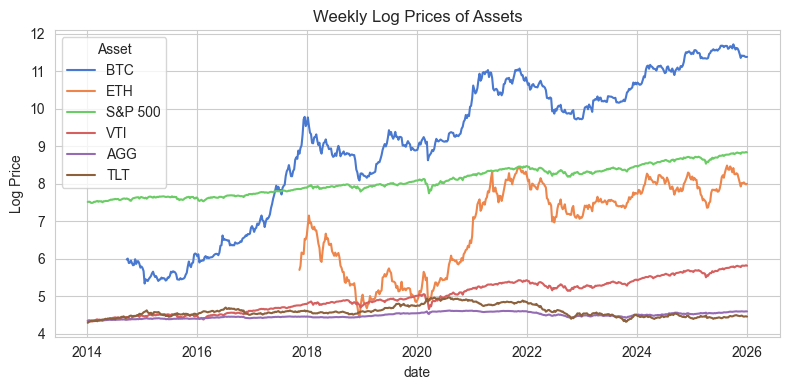

In [47]:
fig, axes = plt.subplots(1, 1, figsize=(8, 4), sharex=True)

# Weekly log prices
g1 = sns.lineplot(
    data=log_weekly_prices_p,
    x='date',
    y='price',
    hue='asset',
    palette='muted',
)

g1.set_title("Weekly Log Prices of Assets")
g1.set_ylabel("Log Price")
g1.legend(title="Asset")

plt.tight_layout()
plt.savefig(plots_dir + "01_weekly_log_prices.png", dpi=500, bbox_inches="tight")
plt.show()

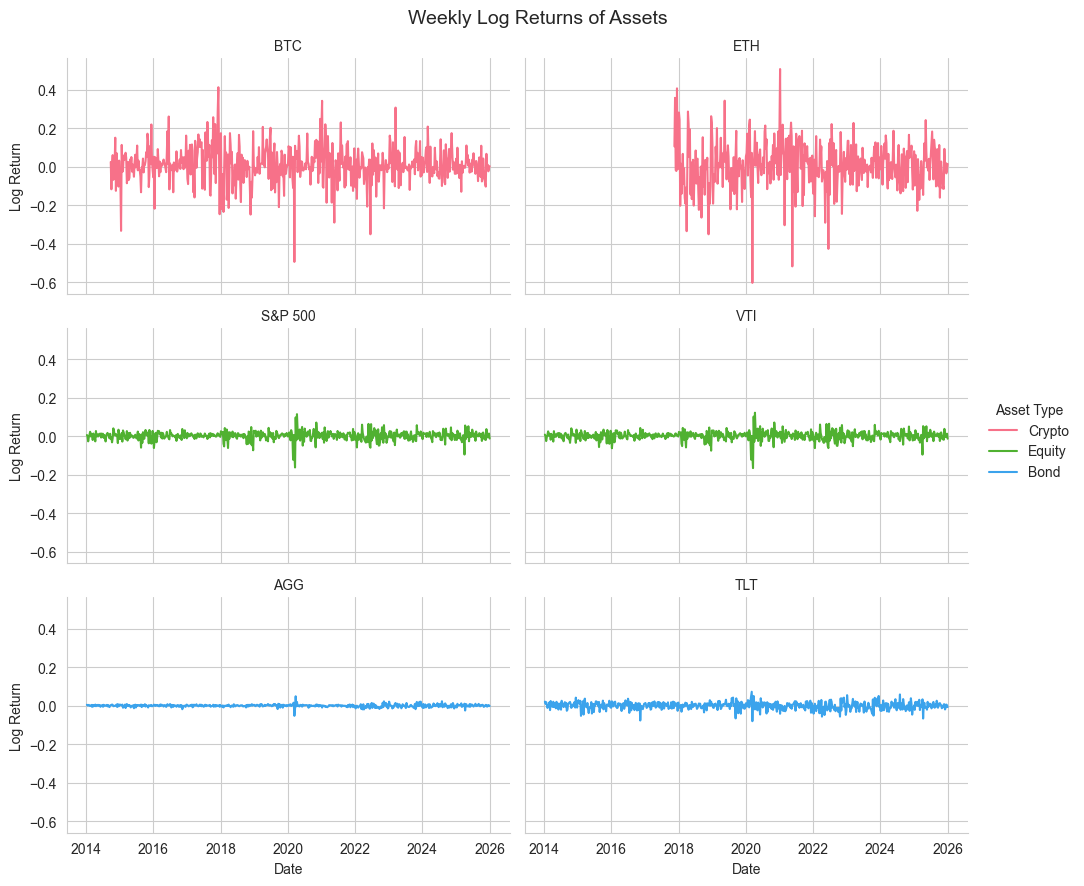

In [48]:
# weekly log returns
g2 = sns.relplot(
    data=log_weekly_returns_p,
    x='date',
    y='price',
    col='asset',
    kind='line',
    col_wrap=2,
    height=3,
    aspect=1.5,
    hue='asset_type',
    palette='husl')

g2.set_titles("{col_name}")
g2.set_axis_labels("Date", "Log Return")
g2.fig.suptitle("Weekly Log Returns of Assets", x=0.55, y=0.98, fontsize=14)
sns.move_legend(g2, "center right", bbox_to_anchor=(1.1, 0.5), title="Asset Type", labels=['Crypto', 'Equity', 'Bond'])

plt.tight_layout()
plt.savefig(plots_dir + "02_weekly_log_returns.png", dpi=500, bbox_inches="tight")
plt.show()